# GFDL-ESM4

In [1]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
from pathlib import Path

### 1. Load model output

In [ ]:
# 1. Load Datasets

# Loading CMIP6 NorCPM1 data for 1pctCO2 experiment
ds_cVeg_1pct = xr.open_mfdataset("../CMIP6 data/GFDL-ESM4/1ptCO2/cVeg_Lmon_GFDL-ESM4_1pctCO2_r1i1p1f1_gr1_*.nc") #Vegetation Carbon
ds_tas_1pct = xr.open_mfdataset("../CMIP6 data/GFDL-ESM4/1ptCO2/tas_Amon_GFDL-ESM4_1pctCO2_r1i1p1f1_gr1_*.nc") #temperature in 1ptCO2 experiment
ds_tas_pi = xr.open_mfdataset("../CMIP6 data/GFDL-ESM4/piControl/tas_Amon_GFDL-ESM4_piControl_r1i1p1f1_gr1_*.nc",
                               combine="by_coords",) #temperature in pre-industrial control experiment

#### check each variable

In [3]:
print(ds_tas_pi['tas'].attrs)
print(ds_tas_1pct['tas'].attrs)
print(ds_cVeg_1pct['cVeg'].attrs)
print(ds_pr_1pct['pr'].attrs)

{'long_name': 'Near-Surface Air Temperature', 'units': 'K', 'cell_methods': 'area: time: mean', 'cell_measures': 'area: areacella', 'standard_name': 'air_temperature', 'interp_method': 'conserve_order2', 'original_name': 'tas'}
{'long_name': 'Near-Surface Air Temperature', 'units': 'K', 'cell_methods': 'area: time: mean', 'cell_measures': 'area: areacella', 'standard_name': 'air_temperature', 'interp_method': 'conserve_order2', 'original_name': 'tas'}
{'long_name': 'Carbon Mass in Vegetation', 'units': 'kg m-2', 'cell_methods': 'area: mean where land time: mean', 'ocean_fillvalue': np.float32(0.0), 'cell_measures': 'area: areacella', 'standard_name': 'vegetation_carbon_content', 'interp_method': 'conserve_order1', 'original_name': 'cVeg', 'comment': 'land_area = areacella * sftlf * 0.01'}
{'long_name': 'Precipitation', 'units': 'kg m-2 s-1', 'cell_methods': 'area: time: mean', 'cell_measures': 'area: areacella', 'standard_name': 'precipitation_flux', 'interp_method': 'conserve_order1',

#### check resolution of model output

In [4]:
# spatial resolution
nominal_res = ds_cVeg_1pct.attrs.get("nominal_resolution", "Not Available")
print(f"Nominal Resolution: {nominal_res}")

# time resolution
file_freq = ds_cVeg_1pct.attrs["frequency"]
print(f"Metadata Frequency: {file_freq}")

Nominal Resolution: 100 km
Metadata Frequency: mon


### 2. Convert time axis to global warming level(GWL)

In [5]:
# ==========================================
# 1. Spatial Averaging for Temperature (Global Mean)
# ==========================================

# Area-weighted global mean temperature for pre-industrial controlled simulation
weights_pi = np.cos(np.deg2rad(ds_tas_pi["lat"]))
weights_pi.name = "weights"
tas_pi_global = (
    ds_tas_pi["tas"].weighted(weights_pi).mean(dim=["lat", "lon"])
)

# Area-weighted global mean temperature for 1ptCO2 experiment
weights_1pct = np.cos(np.deg2rad(ds_tas_1pct["lat"]))
weights_1pct.name = "weights"
tas_1pct_global = (
    ds_tas_1pct["tas"].weighted(weights_1pct).mean(dim=["lat", "lon"])
)

# ==========================================
# 2. Spatial Slicing for cVeg (Keep lat and lon dimensions)
# ==========================================
# Slice the Amazon region
amazon_cVeg_1pct = ds_cVeg_1pct["cVeg"].sel(lat=slice(-20, 10), lon=slice(280, 320))

# Rename variables to prevent conflicts before merging
tas_pi_global = tas_pi_global.rename("tas_pi_global")
tas_1pct_global = tas_1pct_global.rename("tas_1pct_global")
amazon_cVeg_1pct = amazon_cVeg_1pct.rename("cVeg_1pct_amazon")

# ==========================================
# 3. Temporal Resampling to Annual Mean
# ==========================================
# convert monthly data to yearly data(one year average)
tas_pi_annual = tas_pi_global.resample(time="1YS").mean().load()
tas_1pct_annual = tas_1pct_global.resample(time="1YS").mean().load()
cVeg_annual = amazon_cVeg_1pct.resample(time="1YS").mean()

# ==========================================
# 4. Apply 10-year Smoothing to Temperatures
# ==========================================
tas_pi_smoothed = (
    tas_pi_annual.rolling(time=10, center=True, min_periods=1).mean()
)
tas_1pct_smoothed = (
    tas_1pct_annual.rolling(time=10, center=True, min_periods=1).mean()
)

# ==========================================
# 5. Align and Subtract Time-series for GWL
# ==========================================
# Merge smoothed temperatures (1D) and cVeg (3D: time, lat, lon) via inner join
# This aligns the time dimension across variables
cVeg_1pct_amazon_aligned = xr.merge(
    [tas_1pct_smoothed, tas_pi_smoothed, cVeg_annual], join="inner"
)

# Define GWL by subtracting smoothed piControl from 1pctCO2
cVeg_1pct_amazon_aligned["GWL"] = (
    cVeg_1pct_amazon_aligned["tas_1pct_global"] - cVeg_1pct_amazon_aligned["tas_pi_global"]
)

# Set GWL as a coordinate, swap the primary dimension, and sort monotonically
cVeg_1pct_amazon_aligned = (
    cVeg_1pct_amazon_aligned.set_coords("GWL")
    .swap_dims({"time": "GWL"})
    .sortby("GWL")
)

Annual average, with GWL dataset : `cVeg_1pct_amazon_aligned` : (GWL, lat, lon)

this data have annual average of Vegetation carbon content in each grid in Amazon area.

In [6]:
print(cVeg_1pct_amazon_aligned)

<xarray.Dataset> Size: 581kB
Dimensions:           (GWL: 150, lat: 30, lon: 32)
Coordinates:
    time              (GWL) object 1kB 0003-01-01 00:00:00 ... 0150-01-01 00:...
    height            float64 8B 2.0
  * lat               (lat) float64 240B -19.5 -18.5 -17.5 -16.5 ... 7.5 8.5 9.5
  * lon               (lon) float64 256B 280.6 281.9 283.1 ... 316.9 318.1 319.4
  * GWL               (GWL) float64 1kB -0.008147 -0.00433 ... 4.186 4.218
Data variables:
    tas_1pct_global   (GWL) float64 1kB 286.5 286.5 286.5 ... 290.6 290.6 290.6
    tas_pi_global     (GWL) float64 1kB 286.5 286.5 286.5 ... 286.4 286.4 286.4
    cVeg_1pct_amazon  (GWL, lat, lon) float32 576kB dask.array<chunksize=(1, 30, 32), meta=np.ndarray>


#### Model years - GWL(Global Warming Levels)
GWL : After applying '10-year smoothing' to the annual average surface temperature time series of both simulations- 1ptCO2 and piControl-the difference between the two time series at each year

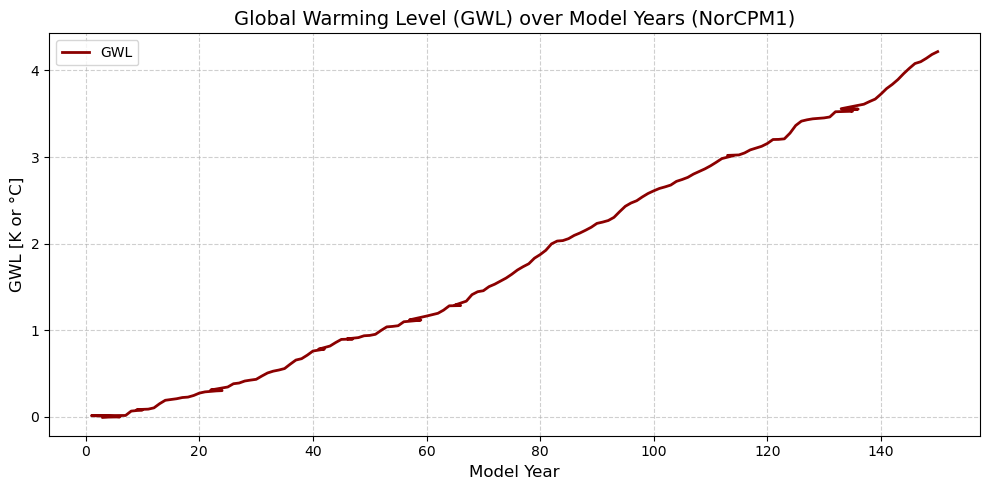

In [7]:

# ==========================================
# 1. Extract X-axis (Years) and Y-axis (GWL)
# ==========================================
# Extract the year component from the xarray time coordinate
model_years = cVeg_1pct_amazon_aligned["time"].dt.year.values
gwl_values = cVeg_1pct_amazon_aligned["GWL"].values

# ==========================================
# 2. Configure and Generate the Plot
# ==========================================
plt.figure(figsize=(10, 5))

# Plot GWL over model years
plt.plot(model_years, gwl_values, color="darkred", linewidth=2, label="GWL")

# Add chart elements
plt.title("Global Warming Level (GWL) over Model Years (NorCPM1)", fontsize=14)
plt.xlabel("Model Year", fontsize=12)
plt.ylabel("GWL [K or °C]", fontsize=12)

# Enable grid lines for better readability
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

### 3. Slicing area using Amazon basin boundary

In [8]:
import geopandas as gpd
import regionmask

# ==========================================
# 1. Load Shapefile and Dissolve Geometry
# ==========================================
amazon_boundary = gpd.read_file(
    "../data/AmazonBasinLimits-master/amazon_sensulatissimo_gmm_v1.shp"
)
if (
    amazon_boundary.crs is not None
    and amazon_boundary.crs.to_string() != "EPSG:4326"
):
    amazon_boundary = amazon_boundary.to_crs(epsg=4326)

amazon_single_basin = amazon_boundary.unary_union

# ==========================================
# 2. Match Coordinates (0~360 to -180~180)
# ==========================================
# Store original [0, 360] longitude for restoration
lon_original = cVeg_1pct_amazon_aligned["lon"]

# Shift longitude values to [-180, 180] to match the shapefile CRS
lon_shifted = cVeg_1pct_amazon_aligned["lon"].where(
    cVeg_1pct_amazon_aligned["lon"] <= 180,
    cVeg_1pct_amazon_aligned["lon"] - 360,
)
cVeg_shifted = cVeg_1pct_amazon_aligned.assign_coords(lon=lon_shifted)

# ==========================================
# 3. Create 2D Mask using regionmask
# ==========================================
basin_region = regionmask.Regions([amazon_single_basin])

# Generate 2D mask matrix matching the grid points
mask = basin_region.mask(
    cVeg_shifted["lon"], cVeg_shifted["lat"], wrap_lon=False
)

# ==========================================
# 4. Apply Mask and Restore Original Coordinates
# ==========================================
# Apply the mask (Keep data where mask equals 0, set others to NaN)
masked_data_shifted = cVeg_shifted.where(mask == 0)

# Restore the original [0, 360] longitude coordinates
amazon_masked_cVeg = masked_data_shifted.assign_coords(lon=lon_original)

/var/folders/jf/2nccqn9j6_74h5ldq21d0y2r0000gn/T/ipykernel_74572/544871316.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  amazon_single_basin = amazon_boundary.unary_union


#### Extract netCDF file from preprocessing

In [9]:
# 1. Rename the variable and coordinates
amazon_masked_cVeg = amazon_masked_cVeg.rename({
    "cVeg_1pct_amazon": "cVeg"
})

# 2. Drop unnecessary temperature variables to leave only 'cVeg'
amazon_masked_cVeg = amazon_masked_cVeg.drop_vars(["tas_1pct_global", "tas_pi_global"])

# 3. Define the output file path
output_nc_path = "amazon_cVeg_for_toad.nc"

# 4. Export the clean xarray Dataset to disk
amazon_masked_cVeg.to_netcdf(output_nc_path)

Now, `amazon_masked_cVeg` is a final .nc data which have (GWL,x,y) in exact amazon basin area. If the center point of each grid in out of boundary, it read it 'NaN'

#### Plot and check data

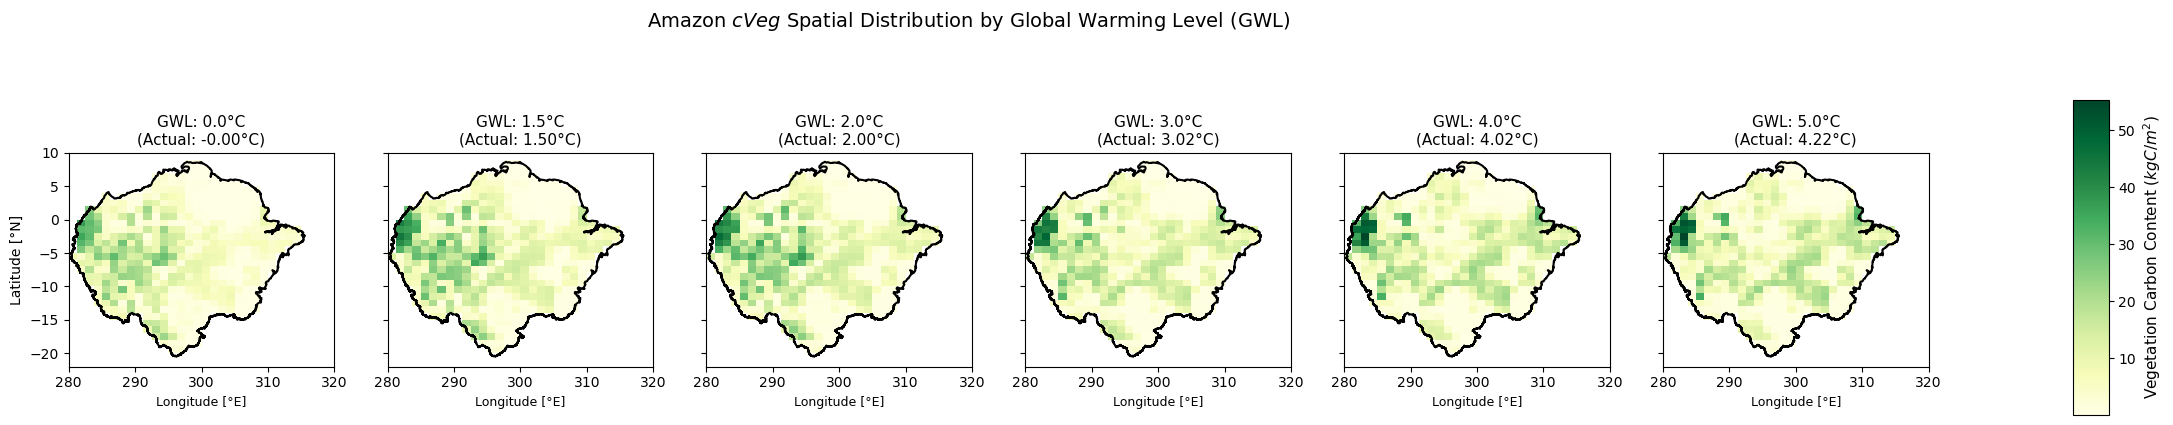

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Extract the specific DataArray using your variable name
# ==========================================
cVeg_data_array = amazon_masked_cVeg["cVeg"]

# ==========================================
# 2. Define Target GWL Levels and Colorbar Limits
# ==========================================
target_gwls = [0.0, 1.5, 2.0, 3.0, 4.0, 5.0]

# Calculate absolute min and max values for the colorbar scale
v_min = float(cVeg_data_array.min(skipna=True))
v_max = float(cVeg_data_array.max(skipna=True))

# Initialize subplots (1 row, 6 columns)
# Width expanded to 24 to prevent horizontal compression of the 6 grids
fig, axes = plt.subplots(1, 6, figsize=(24, 4.5), sharex=True, sharey=True)

# Shift shapefile coordinates to match the [0, 360] longitude grid
amazon_boundary_360 = amazon_boundary.translate(xoff=360)

# ==========================================
# 3. Plot Spatial Maps for Each GWL Threshold
# ==========================================
for ax, target in zip(axes, target_gwls):
    # Select the 2D grid slice nearest to the target GWL value
    cVeg_slice = cVeg_data_array.sel(GWL=target, method="nearest")
    actual_gwl = float(cVeg_slice["GWL"])

    # Plot the 2D spatial grid data
    mesh = ax.pcolormesh(
        cVeg_slice["lon"],
        cVeg_slice["lat"],
        cVeg_slice.values,
        cmap="YlGn",
        vmin=v_min,
        vmax=v_max,
        shading="auto",
    )

    # Overlay the shifted Amazon basin boundary polygon
    amazon_boundary_360.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=1.5
    )

    ax.set_title(
        f"GWL: {target}°C\n(Actual: {actual_gwl:.2f}°C)", fontsize=11
    )
    ax.set_xlabel("Longitude [°E]", fontsize=9)

axes[0].set_ylabel("Latitude [°N]", fontsize=10)

# Add unified colorbar on the right side
# Pushed further right (0.96) to accommodate the wider 6-subplot layout
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Vegetation Carbon Content ($kgC/m^2$)", fontsize=11)

plt.suptitle(
    "Amazon $cVeg$ Spatial Distribution by Global Warming Level (GWL)",
    fontsize=14,
    y=1.05,
)
plt.show()

--- Numerical Trend Summary ---
Initial cVeg (at GWL -0.01°C): 7.2962
Final cVeg (at GWL 4.22°C): 8.7722


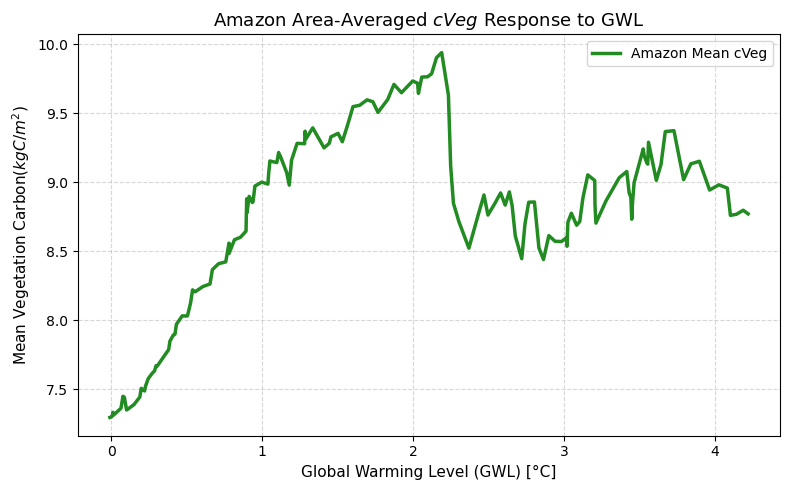

In [11]:
import matplotlib.pyplot as plt
import xarray as xr

# ==========================================
# 1. Load the Exported NetCDF File
# ==========================================
ds_check = xr.open_dataset("amazon_cVeg_for_toad.nc")

# ==========================================
# 2. Calculate Spatial Mean (Ignoring NaN values)
# ==========================================
# Dimensions were renamed to 'x' and 'y' in the previous step
amazon_spatial_mean = ds_check["cVeg"].mean(dim=["lon", "lat"], skipna=True)

# ==========================================
# 3. Print Data Summary for Numerical Verification
# ==========================================
print("--- Numerical Trend Summary ---")
print(f"Initial cVeg (at GWL {amazon_spatial_mean['GWL'].values[0]:.2f}°C): {amazon_spatial_mean.values[0]:.4f}")
print(f"Final cVeg (at GWL {amazon_spatial_mean['GWL'].values[-1]:.2f}°C): {amazon_spatial_mean.values[-1]:.4f}")

# ==========================================
# 4. Plot Mean cVeg vs GWL
# ==========================================
plt.figure(figsize=(8, 5))

# Plot the 1D line using GWL as X-axis
plt.plot(
    amazon_spatial_mean["GWL"],
    amazon_spatial_mean.values,
    color="forestgreen",
    linewidth=2.5,
    label="Amazon Mean cVeg",
)

plt.title("Amazon Area-Averaged $cVeg$ Response to GWL", fontsize=13)
plt.xlabel("Global Warming Level (GWL) [°C]", fontsize=11)
plt.ylabel("Mean Vegetation Carbon($kgC/m^2$)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### Start TOAD

In [12]:
import sys
import os

# Get the parent directory of the 'test' folder
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Target the 'toad-main' directory which contains the actual 'toad' package folder
toad_main_path = os.path.join(parent_dir, "toad-main")

# Add the 'toad-main' path to the system path
if toad_main_path not in sys.path:
    sys.path.append(toad_main_path)

# Now Python can locate the 'toad' folder inside 'toad-main'
from toad import TOAD

output_nc_path = "amazon_cVeg_for_toad.nc"
td = TOAD(output_nc_path, time_dim="GWL")

### Step 1: Compute shifts


In [13]:
from toad.shifts import ASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

# define variable and method
td.compute_shifts(var="cVeg", method=ASDETECT(timescale=(0.05, 0.14)))
# td.compute_shifts(var="cVeg", method=ASDETECT())

# ~12 seconds

Shift detection (960 grid cells in 15 blocks):   0%|          | 0/15 [00:00<?, ?it/s]

INFO: New shifts variable cVeg_dts: min/mean/max=-0.938/-0.010/1.000 using 485 grid cells. Skipped 49.5% grid cells: 475 NaN, 0 constant.


#### Check the single grid - detected series

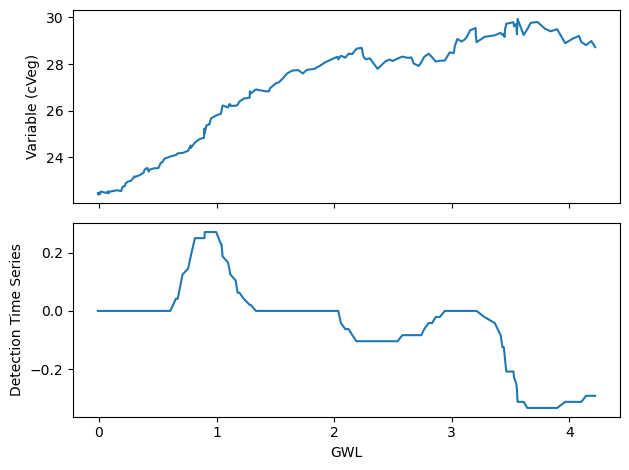

In [14]:
fig, axs = plt.subplots(2, sharex=True)
idx, idy = 4, 10 # Choosing the specific grid

td.data.cVeg.isel(lon=idx, lat=idy).plot(ax=axs[0])
td.data.cVeg_dts.isel(lon=idx, lat=idy).plot(ax=axs[1])
axs[0].set_ylabel("Variable (cVeg)")
axs[1].set_ylabel("Detection Time Series")
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_xlabel("")
fig.tight_layout()

### Clustering

In [15]:
### Including DBSCAN
import numpy as np
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import DBSCAN


class SpaceTimeDBSCAN(ClusterMixin, BaseEstimator):
    """DBSCAN with separate eps for spatial and temporal dimensions.

    Args:
        spatial_eps (float, optional): Epsilon for spatial dimensions in km, if using lat/lon data, else in units of the spatial dimensions
        temporal_eps (float, optional): Epsilon for the temporal dimension in units of the time variable
        min_samples (int): Minimum number of samples in a neighborhood for a point to be
            considered a core point (DBSCAN min_samples).
    """

    skip_time_scaling = True  # Protocol: TOAD skips its time scaling when True

    def __init__(
        self,
        spatial_eps,
        temporal_eps,
        min_samples=5,
    ):
        self.spatial_eps = spatial_eps
        self.temporal_eps = temporal_eps
        self.min_samples = min_samples

    def fit_predict(self, X: np.ndarray, y=None, **kwargs):
        assert y is not None, "y must be provided"

        # Scale time and space independently to control their relative importance
        X_scaled = X.copy()

        # Scale spatial dimensions by spatial_eps
        X_scaled[:, 1:] = X[:, 1:] / self.spatial_eps

        # Scale temporal dimension by temporal_eps
        X_scaled[:, 0] = X[:, 0] / self.temporal_eps

        # Now run DBSCAN with eps=1 (since we pre-scaled)
        dbscan = DBSCAN(eps=1.0, min_samples=self.min_samples, metric="euclidean")
        labels = dbscan.fit_predict(X_scaled)

        return labels

In [170]:
td.data = td.data.drop_vars(td.cluster_vars)

#DBSCAN
td.compute_clusters(
    method=SpaceTimeDBSCAN(
        spatial_eps=1000,
        temporal_eps=0.08,
        min_samples=8
    ),
    shift_direction='negative' # This filter only "decreasing" abrupt shift.
)

# from sklearn.cluster import HDBSCAN
# #HDBSCAN
# td.compute_clusters(
#     var="cVeg",  # reference your base variable, TOAD will find computed shifts for this variable
#     method=HDBSCAN(min_cluster_size=3),
#     time_weight=1.0,#If we use DBSCAN it won't be used
#     shift_direction='negative'
# )

INFO: New cluster variable cVeg_dts_cluster: Identified 1 cluster in 100 pts; Left 69.0% as noise (69 pts).


**DBSCAN parameter**
- **spatial_eps**: (km) How far can you tell it is the similar abrupt shift pattern? 
if one grid where away from 500km, have abrupt shift in the same time with another grid, Can you tell it would be in the same cluster?
our grid resolution is 250km, so if we set this 500km, it covers 2 grid length together.

- **temporal_eps** : (time_unit you set) We seeing vegetation carbon data per each Global warming level - and we have the annual vegetation carbon data, so our unit of time is "GWL(Ceclius degree)" 
Which time step can you tell it is close? at different grids, it show abrupt shifts after 1 degree change(our whole temperature change range is from 1 to 4'C), one showed to the another. Can we say that it should be in the same cluster?



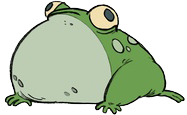

In [171]:
td

In [172]:
# You can find all method parameters used for the computation in the attributes, e.g:
td.data.cVeg_dts.attrs

{'long_name': 'Carbon Mass in Vegetation',
 'units': 'kg m-2',
 'cell_methods': 'area: mean where land time: mean',
 'ocean_fillvalue': np.float32(0.0),
 'cell_measures': 'area: areacella',
 'standard_name': 'vegetation_carbon_content',
 'interp_method': 'conserve_order1',
 'original_name': 'cVeg',
 'comment': 'land_area = areacella * sftlf * 0.01',
 'time_dim': 'GWL',
 'method_name': 'ASDETECT',
 'toad_version': '1.0.7',
 'base_variable': 'cVeg',
 'variable_type': 'shift',
 'shifts_ignore_nan_warnings': 'False',
 'shifts_lmin': '5',
 'shifts_segmentation': 'two_sided',
 'shifts_timescale': '(0.05, 0.14)'}

#### Let's **plot** the result:

TOAD supplies three plotting functions:

- `td.plot.overview()`

- `td.plot.cluster_map()`

- `td.plot.timeseries()`


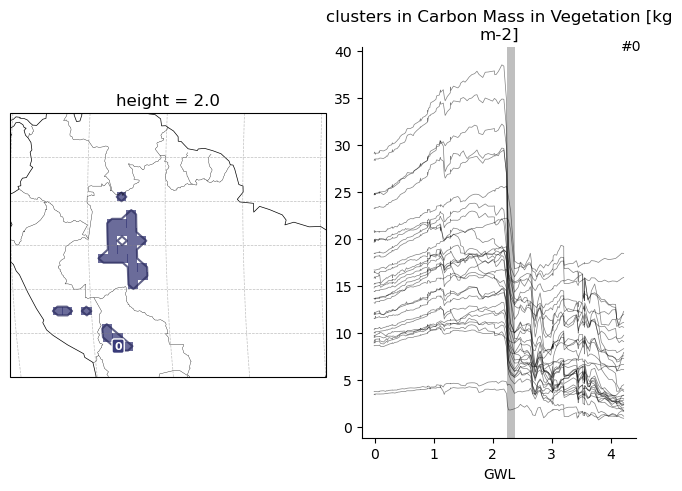

In [173]:
td.plot.overview(map_style={"projection": "global"});

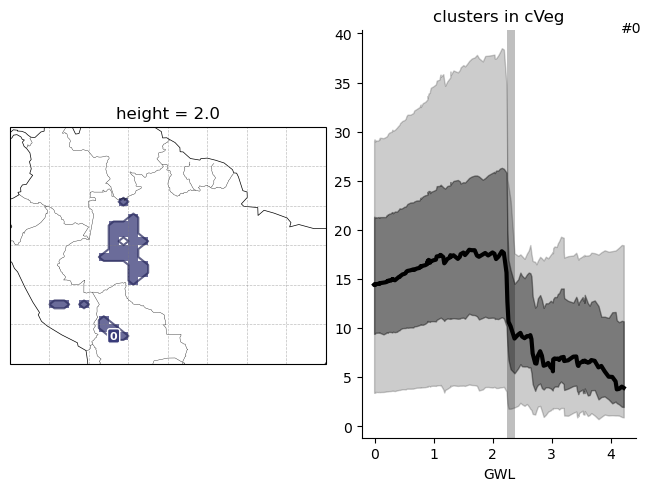

In [174]:
td.plot.overview(mode="aggregated");

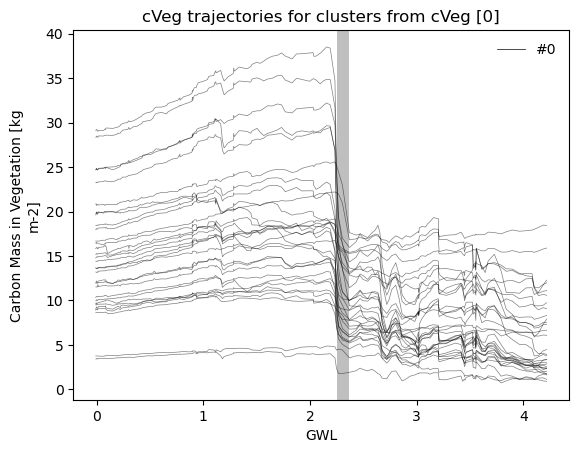

In [175]:
td.plot.timeseries(cluster_ids=[0, 1, 2, 3, 4]);

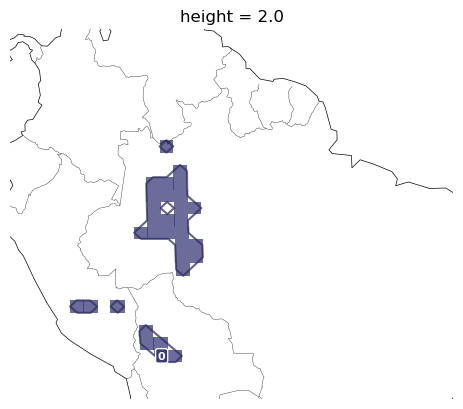

In [176]:
from toad import MapStyle

fig, ax = td.plot.cluster_map(
    cluster_ids=[0,1,2,3,4],
    include_all_clusters=False,
    map_style=MapStyle(projection="global", grid_lines=False),
)
ax.set_axis_off()

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Time of maximum shift for cVeg'}, xlabel='lon', ylabel='lat'>)

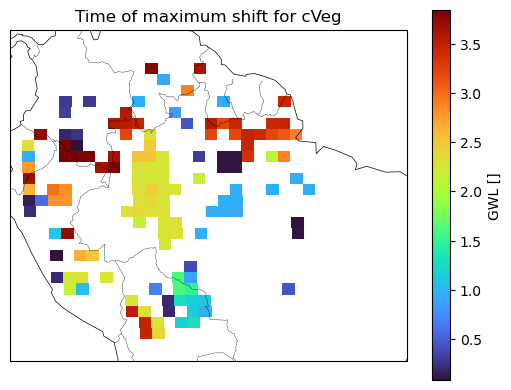

In [177]:
td.plot.time_of_max_shift_map(
    "cVeg", map_style=MapStyle(projection="global", grid_lines=False)
)

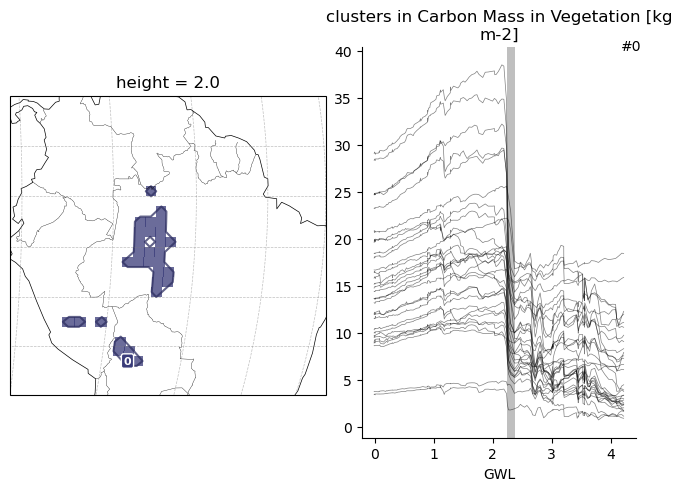

In [178]:
import cartopy.crs as ccrs

# Plot clusters
td.plot.overview("cVeg", map_style={"projection": ccrs.Orthographic(-100, 0)});

# Tip: map style can also be set as a dict, instead of importing the MapStyle class